In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from helpers import get_optimum

file = 'instances/uf100.430.1000/uf100-01.cnf'
get_optimum(file)

File: instances/uf100.430.1000/uf100-01.cnf
Total Clauses: 430
Verified Min Violations (Global Optimum): 0
Verified Max Satisfied Clauses: 430


430

Loaded CNF(from_string='c This Formular is generated by mcnf\nc\nc    horn? no\nc    forced? no\nc    mixed sat? no\nc    clause length = 3\nc\np cnf 100 430\n26 -99 7 0\n-90 84 -94 0\n74 -99 -7 0\n31 5 61 0\n29 16 -10 0\n9 -41 -98 0\n30 46 -43 0\n-78 -5 67 0\n85 -82 22 0\n-69 26 -57 0\n-77 -40 -12 0\n-34 85 13 0\n43 -86 -49 0\n26 -54 -82 0\n88 67 4 0\n16 -21 75 0\n95 29 14 0\n-51 -47 -8 0\n-99 80 31 0\n-58 -14 97 0\n-97 75 -62 0\n100 97 -86 0\n36 -54 -35 0\n-20 52 -70 0\n-80 -89 -10 0\n-17 47 42 0\n35 17 40 0\n9 66 97 0\n33 -28 1 0\n99 58 -21 0\n76 51 18 0\n62 -63 -51 0\n44 91 -47 0\n-89 -67 -82 0\n22 -67 -18 0\n14 -51 1 0\n65 29 -92 0\n97 73 -65 0\n-97 -1 64 0\n-39 -12 -100 0\n7 -67 -24 0\n37 -62 20 0\n-2 73 22 0\n64 -13 34 0\n-61 -30 -34 0\n-33 -92 -54 0\n-48 -36 -13 0\n17 66 -62 0\n71 96 -89 0\n-27 84 -9 0\n48 75 -86 0\n-52 79 -21 0\n53 -63 -50 0\n-90 -70 78 0\n-58 -99 84 0\n60 6 1 0\n29 59 -11 0\n-34 -75 19 0\n65 -78 -88 0\n43 -13 60 0\n-53 -38 25 0\n-86 -12 90 0\n-53 -94 -88 0\n-

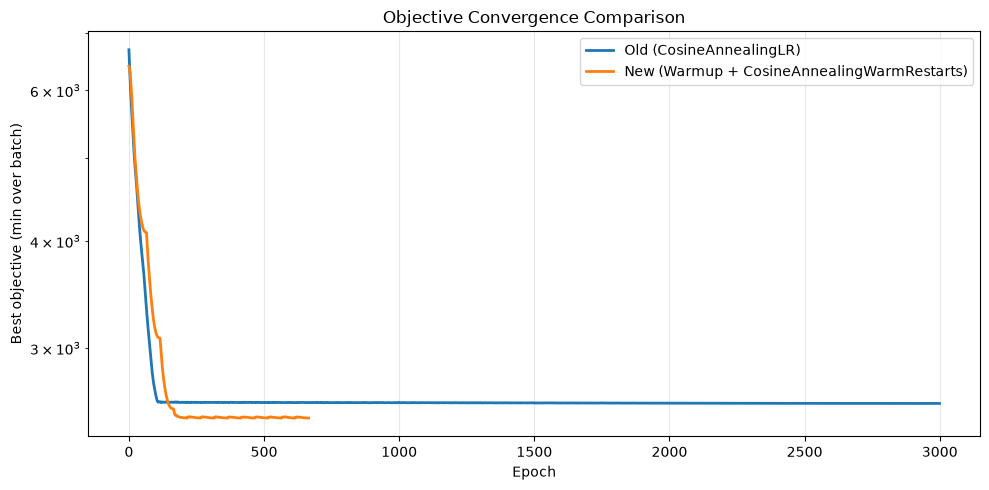

In [30]:
# %% [markdown]
# # A/B Test: Old CosineAnnealingLR vs Warmup + CosineAnnealingWarmRestarts
# 
# This cell compares two learning rate schedules:
# 
# - **Old**: `CosineAnnealingLR` (no warmup, no restarts) – as used in the original `eval.py`
# - **New**: `LinearLR` warmup (10% → 100% of base LR) followed by `CosineAnnealingWarmRestarts` (restart every 50 epochs)

# %%
import torch
import time
import matplotlib.pyplot as plt
from pathlib import Path
from pysat.formula import CNF
from Maxsat_dNN import MaxsatdNN
from helpers import load_cnf_file

# ---------- Helper: count satisfied clauses ----------
def count_satisfied(cnf, theta_var):
    tv = theta_var.detach().cpu().float()
    satisfied = 0
    for clause in cnf.clauses:
        if any(
            (lit > 0 and tv[lit-1] > 0.5) or (lit < 0 and tv[-lit-1] <= 0.5)
            for lit in clause
        ):
            satisfied += 1
    return satisfied

# ---------- Training function with configurable scheduler ----------
def train_maxsat(cnf, scheduler_type='old', 
                 epochs=3000, lr=0.01, theta_batch=8, 
                 grad_clip=1.0, eta_min=1e-4, patience=300, obj_floor=0.01,
                 warmup_epochs=15, restart_period=50):
    """
    Train MaxsatdNN with either 'old' (CosineAnnealingLR) or 'new' (warmup + CosineAnnealingWarmRestarts).
    Returns dict with results and history.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dtype = torch.float32

    B = theta_batch
    solver = MaxsatdNN(cnf, batch_size=B, random_noise=0.1).to(device=device, dtype=dtype)
    with torch.no_grad():
        solver.theta_clause.weight.fill_(1.0)

    optimizer = torch.optim.AdamW([solver.theta_var.weight], lr=lr, weight_decay=1e-4)

    # ----- Scheduler setup -----
    if scheduler_type == 'old':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=eta_min
        )
    elif scheduler_type == 'new':
        # Warmup: linear from 0.1*lr to lr over warmup_epochs
        warmup = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
        )
        # Main: cosine annealing with restarts
        cosine = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=restart_period, T_mult=1, eta_min=eta_min
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs]
        )
    else:
        raise ValueError("scheduler_type must be 'old' or 'new'")

    histories = [[] for _ in range(B)]
    best_obj = float('inf')
    best_theta = None
    no_improve = 0
    start_time = time.time()

    for epoch in range(epochs):
        optimizer.zero_grad()
        obj = solver()
        if B > 1:
            obj.sum().backward()
        else:
            obj.backward()

        torch.nn.utils.clip_grad_norm_([solver.theta_var.weight], grad_clip)
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            solver.theta_var.weight.data.clamp_(0.0, 1.0)

            if B > 1:
                obj_vals = obj.detach().cpu().tolist()
                best_col = int(obj.argmin().item())
                col_min = obj_vals[best_col]
                for c in range(B):
                    histories[c].append(obj_vals[c])
            else:
                col_min = obj.item()
                histories[0].append(col_min)

            if col_min < best_obj - 1e-6:
                best_obj = col_min
                no_improve = 0
                if B > 1:
                    best_theta = solver.theta_var.weight[:, best_col].clone().cpu()
                else:
                    best_theta = solver.theta_var.weight.clone().cpu()
            else:
                no_improve += 1

            if best_obj <= obj_floor or (patience > 0 and no_improve >= patience):
                break

    train_time = time.time() - start_time

    if best_theta is None:
        best_theta = (solver.theta_var.weight[:, 0] if B > 1 else solver.theta_var.weight).clone().cpu()

    satisfied = count_satisfied(cnf, best_theta)
    total_clauses = len(cnf.clauses)
    sat_rate = satisfied / total_clauses if total_clauses else 0.0

    return {
        'scheduler': scheduler_type,
        'best_objective': best_obj,
        'num_satisfied': satisfied,
        'total_clauses': total_clauses,
        'satisfaction_rate': sat_rate,
        'fully_satisfied': satisfied == total_clauses,
        'total_epochs': len(histories[0]),  # actual epochs run
        'train_time_s': train_time,
        'histories': histories,
    }

# ---------- Load a CNF instance ----------
# Replace with your own .cnf file path
cnf = load_cnf_file("instances/uf100.430.1000/uf100-01.cnf")   

print(f"Loaded {cnf}: {cnf.nv} variables, {len(cnf.clauses)} clauses")

# ---------- Run both schedulers ----------
print("\n--- Training with OLD scheduler (CosineAnnealingLR) ---")
old_result = train_maxsat(cnf, scheduler_type='old', epochs=3000, lr=0.01, theta_batch=8)

print("\n--- Training with NEW scheduler (Warmup + CosineAnnealingWarmRestarts) ---")
new_result = train_maxsat(cnf, scheduler_type='new', epochs=3000, lr=0.01, theta_batch=8,
                          warmup_epochs=15, restart_period=50)

# ---------- Compare results ----------
print("\n" + "="*60)
print("COMPARISON")
print("="*60)
print(f"{'Metric':<25} {'Old':>15} {'New':>15}")
print("-"*60)
print(f"{'Best objective':<25} {old_result['best_objective']:>15.6f} {new_result['best_objective']:>15.6f}")
print(f"{'Satisfied clauses':<25} {old_result['num_satisfied']:>15} {new_result['num_satisfied']:>15}")
print(f"{'Satisfaction rate %':<25} {100*old_result['satisfaction_rate']:>14.1f}% {100*new_result['satisfaction_rate']:>14.1f}%")
print(f"{'Fully satisfied':<25} {str(old_result['fully_satisfied']):>15} {str(new_result['fully_satisfied']):>15}")
print(f"{'Epochs used':<25} {old_result['total_epochs']:>15} {new_result['total_epochs']:>15}")
print(f"{'Training time (s)':<25} {old_result['train_time_s']:>15.2f} {new_result['train_time_s']:>15.2f}")
print("="*60)

# ---------- Plot convergence curves (best initialization per epoch) ----------
def plot_best_objective_comparison(old_hist, new_hist):
    """Plot the best objective across batch initializations per epoch."""
    old_best = [min(epoch_vals) for epoch_vals in zip(*old_hist)]
    new_best = [min(epoch_vals) for epoch_vals in zip(*new_hist)]
    plt.figure(figsize=(10, 5))
    plt.plot(old_best, label='Old (CosineAnnealingLR)', linewidth=2)
    plt.plot(new_best, label='New (Warmup + CosineAnnealingWarmRestarts)', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Best objective (min over batch)')
    plt.title('Objective Convergence Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

plot_best_objective_comparison(old_result['histories'], new_result['histories'])

In [23]:
# %% [markdown]
# # A/B Test: Old vs New Scheduler on a Directory of CNF Files
# 
# This script evaluates both schedulers on every `.cnf` file in `--cnf-dir`.
# Results are saved to an output directory with per‑file CSVs and a global comparison table.

# %%
import argparse
import csv
import time
import torch
from pathlib import Path
from pysat.formula import CNF
from Maxsat_dNN import MaxsatdNN
from helpers import load_cnf_file

# ---------- Helper: count satisfied clauses ----------
def count_satisfied(cnf, theta_var):
    tv = theta_var.detach().cpu().float()
    satisfied = 0
    for clause in cnf.clauses:
        if any(
            (lit > 0 and tv[lit-1] > 0.5) or (lit < 0 and tv[-lit-1] <= 0.5)
            for lit in clause
        ):
            satisfied += 1
    return satisfied

# ---------- Training function with configurable scheduler ----------
def train_maxsat(cnf, scheduler_type='old',
                 epochs=300, lr=0.001, theta_batch=8,
                 grad_clip=1.0, eta_min=1e-4, patience=50, obj_floor=0.01,
                 warmup_epochs=20, restart_period=50,
                 seed=42):
    """Train with 'old' (CosineAnnealingLR) or 'new' (warmup + CosineAnnealingWarmRestarts)."""
    torch.manual_seed(seed)  # for reproducibility across runs
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dtype = torch.float32

    B = theta_batch
    solver = MaxsatdNN(cnf, batch_size=B, random_noise=0.1).to(device=device, dtype=dtype)
    with torch.no_grad():
        solver.theta_clause.weight.fill_(1.0)

    optimizer = torch.optim.AdamW([solver.theta_var.weight], lr=lr, weight_decay=1e-4)

    if scheduler_type == 'old':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=eta_min
        )
    elif scheduler_type == 'new':
        warmup = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
        )
        cosine = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=restart_period, T_mult=1, eta_min=eta_min
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs]
        )
    else:
        raise ValueError("scheduler_type must be 'old' or 'new'")

    histories = [[] for _ in range(B)]
    best_obj = float('inf')
    best_theta = None
    no_improve = 0
    start_time = time.time()

    for epoch in range(epochs):
        optimizer.zero_grad()
        obj = solver()
        if B > 1:
            obj.sum().backward()
        else:
            obj.backward()

        torch.nn.utils.clip_grad_norm_([solver.theta_var.weight], grad_clip)
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            solver.theta_var.weight.data.clamp_(0.0, 1.0)

            if B > 1:
                obj_vals = obj.detach().cpu().tolist()
                best_col = int(obj.argmin().item())
                col_min = obj_vals[best_col]
                for c in range(B):
                    histories[c].append(obj_vals[c])
            else:
                col_min = obj.item()
                histories[0].append(col_min)

            if col_min < best_obj - 1e-6:
                best_obj = col_min
                no_improve = 0
                if B > 1:
                    best_theta = solver.theta_var.weight[:, best_col].clone().cpu()
                else:
                    best_theta = solver.theta_var.weight.clone().cpu()
            else:
                no_improve += 1

            if best_obj <= obj_floor or (patience > 0 and no_improve >= patience):
                break

    train_time = time.time() - start_time

    if best_theta is None:
        best_theta = (solver.theta_var.weight[:, 0] if B > 1 else solver.theta_var.weight).clone().cpu()

    satisfied = count_satisfied(cnf, best_theta)
    total_clauses = len(cnf.clauses)
    sat_rate = satisfied / total_clauses if total_clauses else 0.0

    return {
        'scheduler': scheduler_type,
        'best_objective': best_obj,
        'num_satisfied': satisfied,
        'total_clauses': total_clauses,
        'satisfaction_rate': sat_rate,
        'fully_satisfied': satisfied == total_clauses,
        'total_epochs': len(histories[0]),
        'train_time_s': train_time,
        'histories': histories,
    }

# ---------- Process entire directory ----------
def run_on_directory(cnf_dir, output_dir, args):
    cnf_dir = Path(cnf_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    cnf_files = list(cnf_dir.glob(args.pattern))
    if not cnf_files:
        print(f"No files matching {args.pattern} found in {cnf_dir}")
        return

    all_results = []

    for idx, fpath in enumerate(cnf_files):
        name = fpath.stem
        print(f"\n[{idx+1}/{len(cnf_files)}] Processing {name} ...")
        cnf = load_cnf_file(fpath)

        # Run old scheduler
        old_res = train_maxsat(
            cnf, scheduler_type='old',
            epochs=args.epochs, lr=args.lr, theta_batch=args.theta_batch,
            grad_clip=args.grad_clip, eta_min=args.eta_min,
            patience=args.patience, obj_floor=args.obj_floor,
            warmup_epochs=args.warmup_epochs, restart_period=args.restart_period,
            seed=args.seed
        )
        # Run new scheduler
        new_res = train_maxsat(
            cnf, scheduler_type='new',
            epochs=args.epochs, lr=args.lr, theta_batch=args.theta_batch,
            grad_clip=args.grad_clip, eta_min=args.eta_min,
            patience=args.patience, obj_floor=args.obj_floor,
            warmup_epochs=args.warmup_epochs, restart_period=args.restart_period,
            seed=args.seed
        )

        row = {
            'instance': name,
            'old_best_obj': old_res['best_objective'],
            'new_best_obj': new_res['best_objective'],
            'old_satisfied': old_res['num_satisfied'],
            'new_satisfied': new_res['num_satisfied'],
            'total_clauses': old_res['total_clauses'],
            'old_sat_rate': old_res['satisfaction_rate'],
            'new_sat_rate': new_res['satisfaction_rate'],
            'old_fully_sat': old_res['fully_satisfied'],
            'new_fully_sat': new_res['fully_satisfied'],
            'old_epochs': old_res['total_epochs'],
            'new_epochs': new_res['total_epochs'],
            'old_time_s': old_res['train_time_s'],
            'new_time_s': new_res['train_time_s'],
        }
        all_results.append(row)

        # Save per‑instance detailed convergence data (optional)
        inst_dir = output_dir / name
        inst_dir.mkdir(exist_ok=True)
        for res in [old_res, new_res]:
            sched = res['scheduler']
            with open(inst_dir / f'{sched}_epoch_data.csv', 'w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(['init', 'epoch', 'objective'])
                for init_idx, hist in enumerate(res['histories']):
                    for ep, val in enumerate(hist):
                        writer.writerow([init_idx, ep, f'{val:.8f}'])

        print(f"  Old: {old_res['num_satisfied']}/{old_res['total_clauses']} sat, {old_res['train_time_s']:.1f}s")
        print(f"  New: {new_res['num_satisfied']}/{new_res['total_clauses']} sat, {new_res['train_time_s']:.1f}s")

    # Write global comparison CSV
    csv_path = output_dir / 'comparison.csv'
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=all_results[0].keys())
        writer.writeheader()
        writer.writerows(all_results)

    # Print summary
    print("\n" + "="*80)
    print("SUMMARY OVER ALL INSTANCES")
    print("="*80)
    old_fully = sum(1 for r in all_results if r['old_fully_sat'])
    new_fully = sum(1 for r in all_results if r['new_fully_sat'])
    old_avg_rate = sum(r['old_sat_rate'] for r in all_results) / len(all_results)
    new_avg_rate = sum(r['new_sat_rate'] for r in all_results) / len(all_results)
    old_total_time = sum(r['old_time_s'] for r in all_results)
    new_total_time = sum(r['new_time_s'] for r in all_results)

    print(f"Fully satisfied:     Old: {old_fully}/{len(all_results)}   New: {new_fully}/{len(all_results)}")
    print(f"Avg satisfaction:    Old: {100*old_avg_rate:.1f}%          New: {100*new_avg_rate:.1f}%")
    print(f"Total training time: Old: {old_total_time:.1f}s            New: {new_total_time:.1f}s")
    print(f"\nDetailed results saved to: {csv_path}")
    print("="*80)



In [26]:
# Example inline usage (after defining run_on_directory)
args = argparse.Namespace(
    cnf_dir='instances/uf100.430.1000',
    output_dir='ab_test_results_3',
    pattern='*.cnf',
    epochs=300, lr=0.01, theta_batch=8, grad_clip=1.0,
    eta_min=1e-4, patience=50, obj_floor=0.01,weight_decay=1e-3,
    warmup_epochs=20, restart_period=50, seed=42
)
run_on_directory(args.cnf_dir, args.output_dir, args)
print(f"Results saved to {args.output_dir}/comparison.csv")
print(f"Args used: {args}")


[1/1000] Processing uf100-0248 ...
  Old: 398/430 sat, 0.1s
  New: 398/430 sat, 0.1s

[2/1000] Processing uf100-0274 ...
  Old: 404/430 sat, 0.1s
  New: 404/430 sat, 0.1s

[3/1000] Processing uf100-0512 ...
  Old: 401/430 sat, 0.1s
  New: 401/430 sat, 0.1s

[4/1000] Processing uf100-0506 ...
  Old: 405/430 sat, 0.1s
  New: 405/430 sat, 0.1s

[5/1000] Processing uf100-0260 ...
  Old: 404/430 sat, 0.1s
  New: 404/430 sat, 0.1s

[6/1000] Processing uf100-0738 ...
  Old: 399/430 sat, 0.1s
  New: 402/430 sat, 0.1s

[7/1000] Processing uf100-0710 ...
  Old: 404/430 sat, 0.1s
  New: 404/430 sat, 0.1s

[8/1000] Processing uf100-0704 ...
  Old: 413/430 sat, 0.1s
  New: 413/430 sat, 0.1s

[9/1000] Processing uf100-0937 ...
  Old: 407/430 sat, 0.1s
  New: 405/430 sat, 0.1s

[10/1000] Processing uf100-0923 ...
  Old: 400/430 sat, 0.1s
  New: 399/430 sat, 0.1s

[11/1000] Processing uf100-0658 ...
  Old: 396/430 sat, 0.1s
  New: 398/430 sat, 0.1s

[12/1000] Processing uf100-0880 ...
  Old: 408/430 

In [27]:
import pandas as pd
from scipy.stats import wilcoxon

# Load the comparison CSV (adjust path as needed)
df = pd.read_csv('ab_test_results_3/comparison.csv')

# Compute per-instance improvements
df['sat_rate_diff'] = df['new_sat_rate'] - df['old_sat_rate']
df['obj_diff'] = df['old_best_obj'] - df['new_best_obj']   # positive means new better (lower obj)
df['time_diff'] = df['old_time_s'] - df['new_time_s']       # positive means new faster

# Summary statistics
print("=" * 60)
print("COMPARATIVE EVALUATION: Old vs New Scheduler")
print("=" * 60)

print(f"\nNumber of instances: {len(df)}")

# 1. Fully satisfied count
old_fully = df['old_fully_sat'].sum()
new_fully = df['new_fully_sat'].sum()
print(f"\nFully satisfied instances:")
print(f"  Old: {old_fully}/{len(df)} ({100*old_fully/len(df):.1f}%)")
print(f"  New: {new_fully}/{len(df)} ({100*new_fully/len(df):.1f}%)")

# 2. Average satisfaction rate
print(f"\nAverage satisfaction rate:")
print(f"  Old: {df['old_sat_rate'].mean():.4f} ({100*df['old_sat_rate'].mean():.1f}%)")
print(f"  New: {df['new_sat_rate'].mean():.4f} ({100*df['new_sat_rate'].mean():.1f}%)")
print(f"  Mean improvement: {df['sat_rate_diff'].mean():+.4f} ({100*df['sat_rate_diff'].mean():+.1f}%)")

# 3. Average best objective (lower is better)
print(f"\nAverage best objective (lower is better):")
print(f"  Old: {df['old_best_obj'].mean():.6f}")
print(f"  New: {df['new_best_obj'].mean():.6f}")
print(f"  Mean difference (Old - New): {df['obj_diff'].mean():+.6f}")

# 4. Training time
print(f"\nTotal training time (seconds):")
print(f"  Old: {df['old_time_s'].sum():.1f} s")
print(f"  New: {df['new_time_s'].sum():.1f} s")
print(f"  Time saved by new: {df['time_diff'].sum():+.1f} s")

# 5. Epochs used (early stopping)
print(f"\nAverage epochs used:")
print(f"  Old: {df['old_epochs'].mean():.1f}")
print(f"  New: {df['new_epochs'].mean():.1f}")

# 6. Statistical tests (paired, non-parametric)
print("\n" + "-" * 60)
print("STATISTICAL TESTS (Wilcoxon signed-rank, one-sided)")
print("-" * 60)

# Satisfaction rate: test if new > old
if len(df) >= 2:
    stat_sat, p_sat = wilcoxon(df['old_sat_rate'], df['new_sat_rate'], alternative='less')
    print(f"  Satisfaction rate (new > old): p = {p_sat:.5f} {'(significant at α=0.05)' if p_sat < 0.05 else '(not significant)'}")

    # Objective (new < old = better)
    stat_obj, p_obj = wilcoxon(df['old_best_obj'], df['new_best_obj'], alternative='greater')
    print(f"  Best objective (new < old): p = {p_obj:.5f} {'(significant)' if p_obj < 0.05 else '(not significant)'}")

    # Time (new < old = faster)
    stat_time, p_time = wilcoxon(df['old_time_s'], df['new_time_s'], alternative='greater')
    print(f"  Training time (new < old): p = {p_time:.5f} {'(significant)' if p_time < 0.05 else '(not significant)'}")
else:
    print("  Not enough instances for statistical test (need at least 2).")

# 7. Winner count per instance
better_sat = (df['new_sat_rate'] > df['old_sat_rate']).sum()
worse_sat = (df['new_sat_rate'] < df['old_sat_rate']).sum()
tie_sat = (df['new_sat_rate'] == df['old_sat_rate']).sum()
print(f"\nPer‑instance satisfaction rate comparison:")
print(f"  New better: {better_sat} instances")
print(f"  Old better: {worse_sat} instances")
print(f"  Tie:        {tie_sat} instances")

better_obj = (df['new_best_obj'] < df['old_best_obj']).sum()
worse_obj = (df['new_best_obj'] > df['old_best_obj']).sum()
print(f"\nPer‑instance best objective comparison:")
print(f"  New better (lower): {better_obj} instances")
print(f"  Old better:         {worse_obj} instances")

# 8. Final verdict
print("\n" + "=" * 60)
if df['sat_rate_diff'].mean() > 0 and p_sat < 0.05:
    print("✅ The NEW scheduler significantly improves satisfaction rate.")
elif df['sat_rate_diff'].mean() > 0:
    print("📈 The NEW scheduler improves satisfaction rate on average, but not statistically significant.")
else:
    print("⚠️ The NEW scheduler does not show a clear advantage in satisfaction rate.")

if df['obj_diff'].mean() > 0 and p_obj < 0.05:
    print("✅ The NEW scheduler significantly reduces the best objective.")
elif df['obj_diff'].mean() > 0:
    print("📈 The NEW scheduler lowers the objective on average, but not significantly.")

if df['time_diff'].mean() > 0 and p_time < 0.05:
    print("✅ The NEW scheduler is significantly faster.")
elif df['time_diff'].mean() > 0:
    print("📈 The NEW scheduler is faster on average, but not significantly.")
else:
    print("⏱️ Training time is similar between the two.")
print("=" * 60)

COMPARATIVE EVALUATION: Old vs New Scheduler

Number of instances: 1000

Fully satisfied instances:
  Old: 0/1000 (0.0%)
  New: 0/1000 (0.0%)

Average satisfaction rate:
  Old: 0.9400 (94.0%)
  New: 0.9397 (94.0%)
  Mean improvement: -0.0002 (-0.0%)

Average best objective (lower is better):
  Old: 2382.871534
  New: 2389.038983
  Mean difference (Old - New): -6.167449

Total training time (seconds):
  Old: 67.9 s
  New: 66.8 s
  Time saved by new: +1.1 s

Average epochs used:
  Old: 300.0
  New: 297.9

------------------------------------------------------------
STATISTICAL TESTS (Wilcoxon signed-rank, one-sided)
------------------------------------------------------------
  Satisfaction rate (new > old): p = 0.99842 (not significant)
  Best objective (new < old): p = 1.00000 (not significant)
  Training time (new < old): p = 0.00000 (significant)

Per‑instance satisfaction rate comparison:
  New better: 176 instances
  Old better: 253 instances
  Tie:        571 instances

Per‑instan

### Smoke test for Evaluating changes to eval.py and preparing for optuna runs. 

In [ ]:
import torch
from pathlib import Path
from eval import maxsat_dNN_single_cnf
import argparse

args = argparse.Namespace(
    epochs=1000,
    lr=0.09727746954141563,
    batch_size=1,
    grad_clip=1.0,
    eta_min=0.0,
    patience=20,
    weight_decay=5.210905999973664e-05,
    random_noise=0.05,
    warmup_epochs=10,
    restart_period=70,
    restart_samples=50,
    confidence_threshold=0.05,
    max_free_vars =20,

    
)

device = torch.device("cpu")
dtype = torch.float32
cnf_file = Path("instances/vlsat2b/vlsat2_83334_20350783.cnf")
output_dir = Path("vlsat2_83334_20350783")

summary = maxsat_dNN_single_cnf(
    cnf_path=str(cnf_file),
    args=args,
    output_dir=output_dir,
    device=device,
    dtype=dtype,
)

# Print summary (without batch_size, but including params)
for k, v in summary.items():
    print(f"{k:25s}: {v}")

                               

KeyboardInterrupt: 